# <font color="#418FDE" size="6.5" uppercase>**ML Tasks & Data Architecture**</font>

>Last update: 20260324.
    
By the end of this Lecture, you will be able to:
- Differentiate between major ML tasks in ME problems. 
- Describe how ML data points are structured. 
- Explain training, validation, & testing data points & design for a ME ML task. 


## **1. ML Task Types**

### **1.1. ME Prediction Tasks**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_01_01.jpg?v=1774392300" width="250">



>* Prediction estimates unknown outcomes from existing data.
>* It maps inputs to useful engineering outputs.

>* Prediction can be numeric or categorical.
>* Both support uncertain engineering decisions from data.

>* Predictions guide timely engineering decisions.
>* Value depends on meaningful, well-interpreted data.



### **1.2. Feature Extraction Recognition**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_01_02.jpg?v=1774392314" width="250">



>* Feature extraction describes patterns from raw data.
>* Recognition labels conditions using extracted features.

>* Extracts useful patterns from complex raw data
>* Creates features for analysis, not final judgments

>* Recognition labels engineering conditions across many data types.
>* Accuracy depends on realistic, well-defined training data.



### **1.3. Computational Acceleration**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_01_03.jpg?v=1774392330" width="250">



>* ML speeds up repeated engineering simulations.
>* Surrogate models enable fast, useful estimates.

>* Acceleration predicts model outputs, not measurements.
>* Speeds optimization and uncertainty studies.

>* Speed helps, but reliability limits usefulness.
>* Best for screening with occasional verification.



## **2. Data Point Structure**

### **2.1. Features and Labels**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_02_01.jpg?v=1774392350" width="250">



>* Data points contain features and often labels.
>* Features describe examples; labels are targets.

>* Good features are relevant and consistent.
>* Labels vary in source and quality.

>* Learning tasks determine feature-label structure.
>* Use only prediction-time features, not outcomes.



In [14]:
#@title Python Code - Features and Labels

# This script shows features and labels.
# Mechanical engineering examples use simple arrays.
# We compare tabular image and time-series.

import numpy as np

# Set a seed for repeatability.
np.random.seed(7)

# Build one tabular mechanical component record.
tabular_features = np.array([25, 12000, 3.2, 6])
tabular_label = 12

# Build one small crack image.
image_features = np.array([
    [0, 1, 1, 0],

    [1, 1, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 0]])

image_label = "crack"

# Build one vibration time series.
time_features = np.array([0.10, 0.14, 0.18, 0.16, 0.11])
time_label = "normal"

# Check the example shapes safely.
print("Tabular feature count:", tabular_features.shape[0])
print("Tabular label:", tabular_label)

print("Image feature shape:", image_features.shape)
print("Image label:", image_label)

# Show time-series structure clearly.
print("Time-series length:", time_features.shape[0])
print("Time-series label:", time_label)

print("First image row:", image_features[0])
print("Tabular features:", tabular_features)


Tabular feature count: 4
Tabular label: 12
Image feature shape: (4, 4)
Image label: crack
Time-series length: 5
Time-series label: normal
First image row: [0 1 1 0]
Tabular features: [2.5e+01 1.2e+04 3.2e+00 6.0e+00]


### **2.2. Data Formats**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_02_02.jpg?v=1774392374" width="250">



>* Data format shapes machine learning representation.
>* Tabular data uses rows, columns, labels.

>* Images preserve spatial patterns for recognition.
>* Labels classify pressure vesselage or locate defects.

>* Time-series data preserves order and changing patterns.
>* Labels describe future outcomes or conditions.



Tabular shape: (3, 4)
Tabular features: ['span_m', 'age_years', 'system throughput_kpd']
Tabular label: repair_priority
Image shape: (8, 8)
Image label: crack_present = 1
Time-series length: 12
Time-series label: pressure vesselage_state = elevated


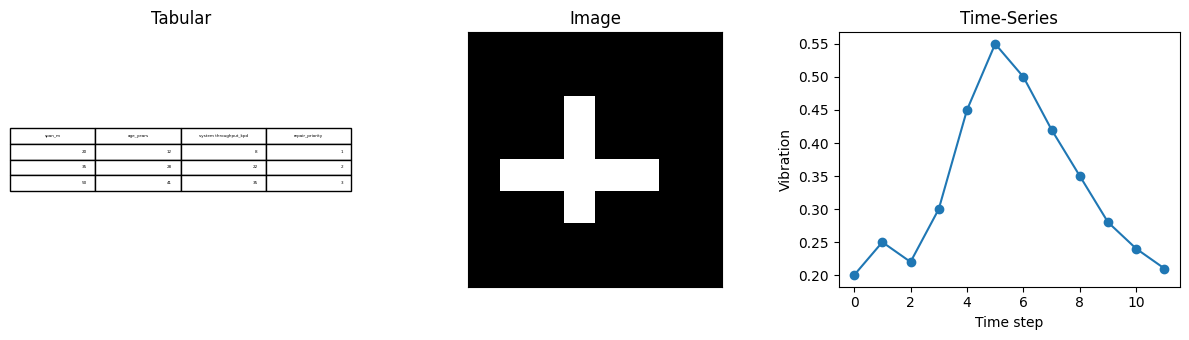

In [15]:
#@title Python Code - Data Formats

# This script shows three engineering data formats.
# We compare rows, pixels, and sequences.
# The examples stay small and beginner friendly.

# Import simple plotting and data tools.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Set a seed for repeatable values.
np.random.seed(7)

# Build small tabular mechanical component data.
tabular_data = pd.DataFrame({
    "span_m": [20, 35, 50],

    "age_years": [12, 28, 41],
    "system throughput_kpd": [8, 22, 35],
    "repair_priority": [1, 2, 3]})

# Build a tiny crack image example.
image_data = np.zeros((8, 8))
image_data[2:6, 3] = 1

image_data[4, 1:6] = 1

# Build a short vibration time series.
time_steps = np.arange(12)
time_series = np.array([

    0.20, 0.25, 0.22, 0.30,
    0.45, 0.55, 0.50, 0.42,
    0.35, 0.28, 0.24, 0.21])

# Print short summaries for each format.
print("Tabular shape:", tabular_data.shape)
print("Tabular features:", ["span_m", "age_years", "system throughput_kpd"])

print("Tabular label:", "repair_priority")
print("Image shape:", image_data.shape)
print("Image label:", "crack_present = 1")

print("Time-series length:", len(time_series))
print("Time-series label:", "pressure vesselage_state = elevated")

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Show the tabular data table.
axes[0].axis("off")
axes[0].table(

    cellText=tabular_data.values,
    colLabels=tabular_data.columns,
    loc="center")

axes[0].set_title("Tabular")

# Show the image data pixels.
axes[1].imshow(image_data, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Image")

axes[1].set_xticks([])
axes[1].set_yticks([])

# Show the time-series sequence.
axes[2].plot(time_steps, time_series, marker="o")
axes[2].set_title("Time-Series")

axes[2].set_xlabel("Time step")
axes[2].set_ylabel("Vibration")

# Tighten layout for clear viewing.
plt.tight_layout()
plt.show()


### **2.3. Data Point Anatomy**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_02_03.jpg?v=1774392399" width="250">



>* Each data point is one structured observation.
>* Features and labels stay consistent across data.

>* Data points vary across tables, images, time-series.
>* Time order matters for sequential measurements.

>* Data point boundaries shape learning problems.
>* Consistent structure enables reliable, comparable examples.



In [16]:
#@title Python Code - Data Point Anatomy

# This script shows data point anatomy.
# We compare three common data formats.
# Each example uses simple mechanical data.

# Import NumPy for small arrays.
import numpy as np

# Set a seed for repeatability.
np.random.seed(7)

# Build one tabular data point.
tabular_features = np.array([420, 0.45, 28, 19])
tabular_label = 35.6

# Build one image style data point.
image_pixels = np.array([
    [0, 1, 0, 0],

    [1, 1, 1, 0],
    [0, 1, 1, 1],
    [0, 0, 1, 0]])

# Add a simple image label.
image_label = "crack present"

# Build one time series data point.
time_series_features = np.array([0.12, 0.15, 0.18, 0.22, 0.20, 0.17])
time_series_label = "normal vibration"

# Check the small shapes safely.
print("Tabular feature count:", tabular_features.shape[0])
print("Tabular label:", tabular_label)

print("Image shape:", image_pixels.shape)
print("Image label:", image_label)

# Show time order matters here.
print("Time-series length:", time_series_features.shape[0])
print("Time-series label:", time_series_label)

print("First three time values:", time_series_features[:3])
print("One data point means one complete observation.")


Tabular feature count: 4
Tabular label: 35.6
Image shape: (4, 4)
Image label: crack present
Time-series length: 6
Time-series label: normal vibration
First three time values: [0.12 0.15 0.18]
One data point means one complete observation.


## **3. Data Splits**

### **3.1. Data Split Roles**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_03_01.jpg?v=1774392424" width="250">



>* Training data teaches patterns from labeled examples.
>* Training accuracy alone may not generalize.

>* Validation guides model choices during development.
>* It checks generalization without direct training.

>* Test data gives final real-world evaluation.
>* Separate tests prevent false confidence.



In [17]:
#@title Python Code - Data Split Roles

# This script explains simple data split roles.
# We use a small mechanical dataset.
# Results show training validation testing sizes.

# Import basic tools for tables.
import random
import pandas as pd

# Set a seed for repeatability.
random.seed(7)

# Build a tiny mechanical component dataset.
mechanical_component_age = list(range(5, 65, 5))
system_throughput_load = [12, 15, 18, 20, 24, 27, 30, 34, 37, 40, 44, 48]

# Add condition ratings manually.
condition_rating = [92, 89, 86, 84, 80, 77, 73, 69, 66, 62, 58, 54]
df = pd.DataFrame({

    "mechanical_component_age": mechanical_component_age,
    "system_throughput_load": system_throughput_load,
    "condition_rating": condition_rating})

# Shuffle rows before splitting.
df = df.sample(frac=1, random_state=7).reset_index(drop=True)

# Compute split sizes safely.
total_rows = len(df)
train_end = int(total_rows * 0.6)

valid_end = int(total_rows * 0.8)

# Create three separate groups.
train_df = df.iloc[:train_end]
valid_df = df.iloc[train_end:valid_end]

test_df = df.iloc[valid_end:]

# Check that all rows were used.
used_rows = len(train_df) + len(valid_df) + len(test_df)
print("Total data points:", total_rows)

print("Rows used after split:", used_rows)

# Explain each split briefly.
print("Training set learns patterns from known examples.")
print("Validation set helps compare model choices.")

print("Test set gives final unbiased performance check.")

# Show split sizes clearly.
print("Training rows:", len(train_df))
print("Validation rows:", len(valid_df))

print("Testing rows:", len(test_df))

# Show one example from each split.
print("Train example:", train_df.iloc[0].to_dict())
print("Validation example:", valid_df.iloc[0].to_dict())

print("Test example:", test_df.iloc[0].to_dict())


Total data points: 12
Rows used after split: 12
Training set learns patterns from known examples.
Validation set helps compare model choices.
Test set gives final unbiased performance check.
Training rows: 7
Validation rows: 2
Testing rows: 3
Train example: {'mechanical_component_age': 40, 'system_throughput_load': 34, 'condition_rating': 69}
Validation example: {'mechanical_component_age': 45, 'system_throughput_load': 37, 'condition_rating': 66}
Test example: {'mechanical_component_age': 35, 'system_throughput_load': 30, 'condition_rating': 73}


### **3.2. Train Test Split**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_03_02.jpg?v=1774392450" width="250">



>* Training learns patterns; testing checks new cases.
>* Splits reveal generalization, not memorization.

>* Choose splits based on real use.
>* Test data must reflect full diversity.

>* Split by time, site, or project.
>* Match real use and avoid leakage.



In [18]:
#@title Python Code - Train Test Split

# This script shows a simple data split.
# Mechanical engineering examples use mechanical component strength data.
# Training and testing sets have different roles.

# Import basic libraries for this lesson.
import random
import numpy as np

import pandas as pd

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

# Create a small mechanical materials dataset.
data = pd.DataFrame({
    "cement": np.random.randint(250, 451, 20),

    "water": np.random.randint(140, 221, 20),
    "age_days": np.random.randint(7, 91, 20),
    "strength": np.random.randint(20, 61, 20)})

# Shuffle row positions before splitting.
indices = list(data.index)
random.shuffle(indices)

# Choose an eighty twenty split.
split_point = int(0.8 * len(indices))
train_ids = indices[:split_point]

test_ids = indices[split_point:]

# Build training and testing tables.
train_data = data.loc[train_ids].reset_index(drop=True)
test_data = data.loc[test_ids].reset_index(drop=True)

# Separate inputs and output column.
X_train = train_data[["cement", "water", "age_days"]]
y_train = train_data["strength"]

X_test = test_data[["cement", "water", "age_days"]]
y_test = test_data["strength"]

# Check that the split is valid.
print("Total rows:", len(data))
print("Training rows:", len(train_data))

print("Testing rows:", len(test_data))
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("First training target:", y_train.iloc[0])
print("First testing target:", y_test.iloc[0])
print("Train and test overlap:", set(train_ids).intersection(set(test_ids)))


Total rows: 20
Training rows: 16
Testing rows: 4
Training features shape: (16, 3)
Testing features shape: (4, 3)
First training target: 49
First testing target: 52
Train and test overlap: set()


### **3.3. Why Splits Matter**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_A/image_03_03.jpg?v=1774392474" width="250">



>* Splits test learning beyond memorized training data.
>* They simulate future mechanical engineering use.

>* Validation controls bias during model selection.
>* Separate splits improve generalization to new conditions.

>* Splits should match real deployment conditions.
>* Careful splits improve trust and generalization.



Mechanical engineering example: mechanical component condition prediction
Random split test error: 1.79
Time split test error: 22.28
Lower random error can look better than reality.
Time split better matches future deployment.


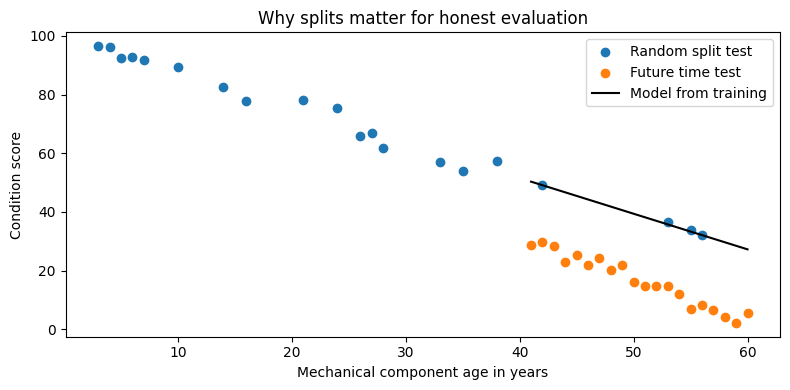

In [19]:
#@title Python Code - Why Splits Matter

# Data splits protect honest model evaluation.
# Mechanical engineering models must generalize well.
# This example shows leakage problems clearly.

# Import small teaching libraries.
import random
import numpy as np

import matplotlib.pyplot as plt

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

# Build simple mechanical component age data.
ages = np.arange(1, 61, 1)
noise = np.random.normal(0, 2, len(ages))

condition = 100 - 1.2 * ages + noise

# Create future deterioration shift.
future_noise = np.random.normal(0, 2, len(ages))
future_condition = 92 - 1.5 * ages + future_noise

# Fit a simple straight line.
def fit_line(x, y):
    slope, intercept = np.polyfit(x, y, 1)

    return slope, intercept

# Predict using the fitted line.
def predict_line(x, slope, intercept):
    return slope * x + intercept

# Measure average absolute error.
def mean_abs_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Make a careless random split.
all_ids = list(range(len(ages)))
random.shuffle(all_ids)

train_ids = all_ids[:40]
test_ids = all_ids[40:]

# Prepare random split arrays.
x_train_random = ages[train_ids]
y_train_random = condition[train_ids]

x_test_random = ages[test_ids]
y_test_random = condition[test_ids]

# Train and test random split.
m1, b1 = fit_line(x_train_random, y_train_random)
pred_random = predict_line(x_test_random, m1, b1)

error_random = mean_abs_error(y_test_random, pred_random)

# Make a realistic time split.
x_train_time = ages[:40]
y_train_time = condition[:40]

x_test_time = ages[40:]
y_test_time = future_condition[40:]

# Train and test time split.
m2, b2 = fit_line(x_train_time, y_train_time)
pred_time = predict_line(x_test_time, m2, b2)

error_time = mean_abs_error(y_test_time, pred_time)

# Print the key lesson.
print("Mechanical engineering example: mechanical component condition prediction")
print("Random split test error:", round(error_random, 2))

print("Time split test error:", round(error_time, 2))
print("Lower random error can look better than reality.")
print("Time split better matches future deployment.")

# Plot both testing situations.
plt.figure(figsize=(8, 4))
plt.scatter(x_test_random, y_test_random, label="Random split test")

plt.scatter(x_test_time, y_test_time, label="Future time test")

# Add the learned prediction line.
plt.plot(x_test_time, pred_time, color="black", label="Model from training")
plt.xlabel("Mechanical component age in years")

plt.ylabel("Condition score")

# Finish the teaching figure.
plt.title("Why splits matter for honest evaluation")
plt.legend()

plt.tight_layout()
plt.show()


# <font color="#418FDE" size="6.5" uppercase>**ML Tasks & Data Architecture**</font>


In this lecture, you learned to:
- Differentiate between major ML tasks in ME problems. 
- Describe how ML data points are structured. 
- Explain training, validation, & testing data points & design for a ME ML task. 

In the next Lecture (Lecture B), we will go over 'Learning Problems & Evaluation'